In [1]:
# --! include root folder into PYTHONPATH ---------------------------------!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

In [2]:
import numpy as np
import pickle
from matplotlib import pyplot as plt

import utils_data
import utils_kalman

In [3]:
dt                 = 0.01
timeseries_nsample = 200
testdata           = utils_data.read_datafile('../../data/kalman/test_sim/eval', timeseries_nsample).detach().numpy()

# --! test data is a batch/array with timeseries, but we want one long timeseries, so reshape
testdata           = testdata.reshape(-1, testdata.shape[-1])

timeseries_dur = testdata.shape[0] * dt
t = np.arange(0., timeseries_dur, dt).reshape(-1, 1)

# --! field gradient is 10 MV/m, but since we simulate only one cell,
# --! and one cell is approximately 0.1615 meters, then
# --! we need to adjust the total gradient
grad = 10 * 0.1615
u  = np.array([[np.square(grad)]])

### Single model

In [4]:
param = {
    'dt' :   dt,
    'f'  :   1.,
    'q'  :   20.,
    'k'  :   1.
}
kf1 = utils_kalman.filter_detuning(param)

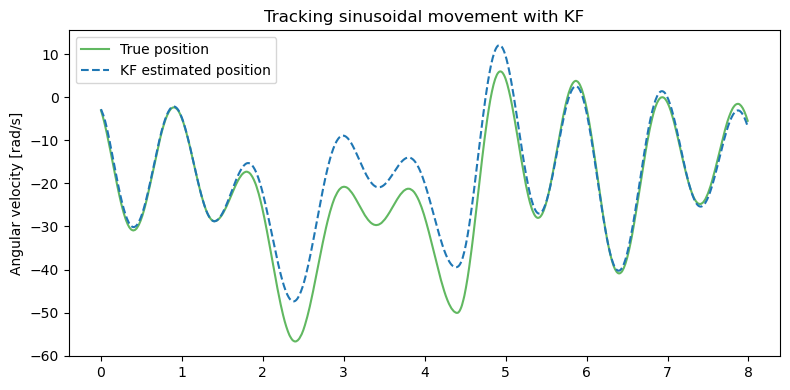

In [5]:
kf_pos             = []
es                 = []

for j in range(testdata.shape[0]):
    # measurement
    z = testdata[j, 0]

    # Kalman filter step
    kf1.predict(u=u)
    kf1.update(np.array([z]))

    kf_pos.append(kf1.x[0])

kf_pos = np.array(kf_pos).reshape(-1, 1)

plt.figure(figsize=(8, 4))

plt.plot(t, testdata, label='True position', color='tab:green', alpha=0.75, linestyle='solid')
plt.plot(t, kf_pos, label='KF estimated position', color='tab:blue', alpha=1., linestyle='dashed')
plt.ylabel('Angular velocity [rad/s]')
plt.legend()
plt.title('Tracking sinusoidal movement with KF')
plt.tight_layout()

plt.show()

datasaved = True
if datasaved:
    savedata = np.expand_dims(np.concatenate([t, testdata, kf_pos], axis=1), 0)
    utils_data.write_datafile('../../savedata/kalman/kf_single_sim', savedata, delim=' ')

### Multiple models with a threshold-based switch

In [6]:
# --!-------------------------------------------------------------!
# --! 

param = {
    'dt' :   dt,
    'f'  :   1.,
    'q'  :   20.,
    'k'  :   1.
}
kf1 = utils_kalman.filter_detuning(param)

param['f'] = 0.5
param['q'] = 10.
kf05 = utils_kalman.filter_detuning(param)

# --! residual threshold to switch between filters
threshold = 3.


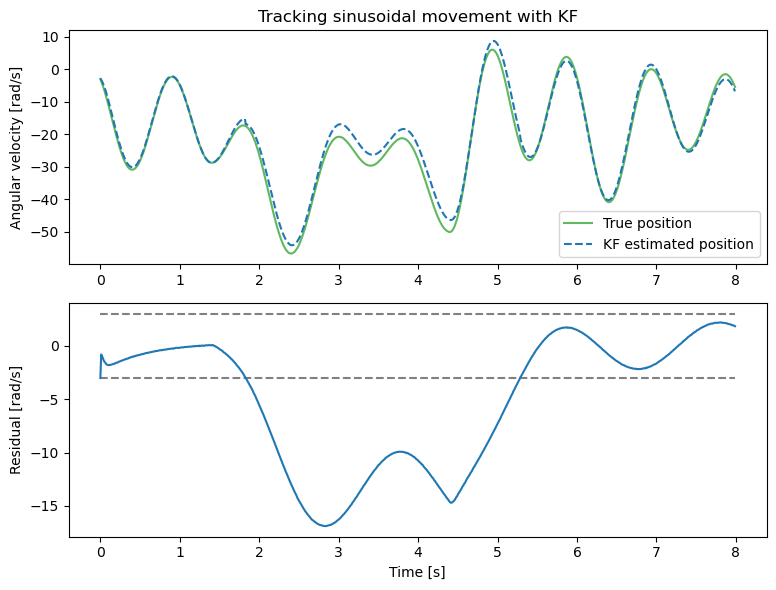

In [7]:
kf_pos             = []
es                 = []

for j in range(testdata.shape[0]):
    # measurement
    z = testdata[j, 0]

    # Kalman filter step
    kf1.predict(u=u)
    kf1.update(np.array([z]))

    kf05.predict(u=u)
    kf05.update(np.array([z]))

    e = np.squeeze(kf1.y)
    es.append(e)

    # store filtered position
    if abs(e) < threshold:
        kf_pos.append(kf1.x[0])
    else:
        kf_pos.append(kf05.x[0])

kf_pos = np.array(kf_pos).reshape(-1, 1)
es = np.array(es).reshape(-1, 1)

plt.figure(figsize=(8, 6))

plt.subplot(2, 1, 1)
plt.plot(t, testdata, label='True position', color='tab:green', alpha=0.75, linestyle='solid')
plt.plot(t, kf_pos, label='KF estimated position', color='tab:blue', alpha=1., linestyle='dashed')
plt.ylabel('Angular velocity [rad/s]')
plt.legend()
plt.title('Tracking sinusoidal movement with KF')
plt.tight_layout()

threshold_line_up = np.ones_like(t) * threshold
threshold_line_down = -1 * np.ones_like(t) * threshold
plt.subplot(2, 1, 2)
plt.plot(t, threshold_line_up, color='gray', linestyle='dashed')
plt.plot(t, threshold_line_down, color='gray', linestyle='dashed')
plt.plot(t, es)
plt.xlabel('Time [s]')
plt.ylabel('Residual [rad/s]')
plt.tight_layout()

plt.show()

datasaved = True
if datasaved:
    savedata = np.expand_dims(np.concatenate([t, testdata, kf_pos, es], axis=1), 0)
    utils_data.write_datafile('../../savedata/kalman/kf_mm_threshold_sim', savedata, delim=' ')

### Mutiple models with a likelihood-based switch

In [8]:
# --!-------------------------------------------------------------!
# --! make a filter bank with two filters:
# --! *       1 Hz with Q=20
# --! *     0.5 Hz with Q=10

param = {
    'dt' :   dt,
    'f'  :   1.,
    'q'  :   20.,
    'k'  :   1.
}
kf1 = utils_kalman.filter_detuning(param)

param['f'] = 0.5
param['q'] = 10.
kf05 = utils_kalman.filter_detuning(param)

p1, p05 = 0.5, 0.5
p1sum, p05sum = 0., 0.

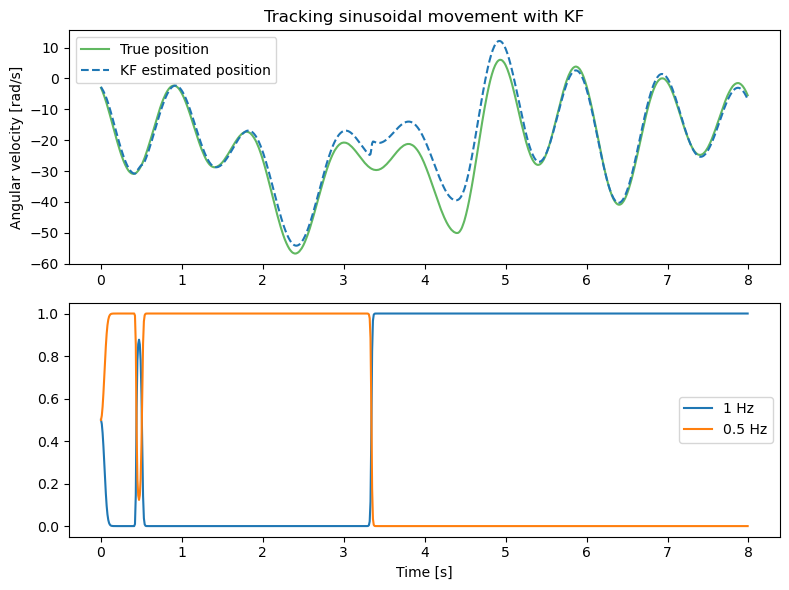

In [9]:
kf_pos = []
p1s    = []
p05s   = []

for j in range(testdata.shape[0]):
    # measurement
    z = testdata[j, 0]

    kf1.predict(u=u)
    kf1.update(np.array([z]))

    kf05.predict(u=u)
    kf05.update(np.array([z]))

    y1, S1         = kf1.y, kf1.S
    kf1_likelihood = y1.T @ np.linalg.inv(S1) @ y1
    kf1_likelihood = kf1_likelihood * p1
    kf1_likelihood = np.squeeze(kf1_likelihood)

    y05, S05         = kf05.y, kf05.S
    kf05_likelihood  = y05.T @ np.linalg.inv(S05) @ y05
    kf05_likelihood  = kf05_likelihood * p05
    kf05_likelihood  = np.squeeze(kf05_likelihood)

    p1 = (kf1_likelihood) / (kf1_likelihood + kf05_likelihood)
    p05 = (kf05_likelihood) / (kf1_likelihood + kf05_likelihood)

    x = (p1 * kf1.x[0]) + (p05 * kf05.x[0])

    kf_pos.append(x)
    p1s.append(p1)
    p05s.append(p05)

# --! convert lists to numpy column vectors
kf_pos = np.array(kf_pos).reshape(-1, 1)
p1s    = np.array(p1s).reshape(-1, 1)
p05s   = np.array(p05s).reshape(-1, 1)

plt.figure(figsize=(8, 6))

plt.subplot(2, 1, 1)
plt.plot(t, testdata, label='True position', color='tab:green', alpha=0.75, linestyle='solid')
plt.plot(t, kf_pos, label='KF estimated position', color='tab:blue', alpha=1., linestyle='dashed')
plt.ylabel('Angular velocity [rad/s]')
plt.legend()
plt.title('Tracking sinusoidal movement with KF')
plt.tight_layout()

plt.subplot(2, 1, 2)
plt.plot(t, p1s, label='1 Hz')
plt.plot(t, p05s, label='0.5 Hz')
plt.legend()
plt.xlabel('Time [s]')
plt.tight_layout()

plt.show()

datasaved = True
if datasaved:
    savedata = np.expand_dims(np.concatenate([t, testdata, kf_pos, p1s, p05s], axis=1), 0)
    utils_data.write_datafile('../../savedata/kalman/kf_mm_likelihood_sim', savedata, delim=' ')